In [52]:
# =========================
# [Cell 1] 기본 설정
# =========================
import os, json
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer

# 너 코드
from mnl_router import MNLRouter

# ---- 유저가 바꿔야 하는 것 ----
DATA_PATH = "/home/sjy990426/Desktop/LLM_Router/Queing_MNL_Router/routerbench_0shot.pkl"
OUT_DIR = "./runs_B_only_check_notebook"

Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

print("DATA_PATH =", DATA_PATH)
print("OUT_DIR   =", OUT_DIR)


DATA_PATH = /home/sjy990426/Desktop/LLM_Router/Queing_MNL_Router/routerbench_0shot.pkl
OUT_DIR   = ./runs_B_only_check_notebook


In [53]:
# =========================
# [Cell 2] Config / 데이터 로딩 유틸
# =========================
@dataclass
class BPretrainConfig:
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    test_size: float = 0.3

    use_cost: bool = True
    lam_cost: float = 50.0

    embedder_model: str = "sentence-transformers/all-MiniLM-L6-v2"

    offline_total_ratio: float = 0.2
    tb_win_frac: float = 0.3
    tb_rand_frac: float = 0.7

    d_proj: int = 64
    supcon_temp: float = 0.1
    b_type: str = "mlp"          # "linear" or "mlp"
    b_hidden_mult: int = 2

    offline_lr_B: float = 3e-4
    offline_epochs: int = 10000
    supcon_bs: int = 512

    supcon_pos_strategy: str = "topr_mass"   # "top1" / "topr_mass" / "topr_margin"
    supcon_topk_max_k: int = 2
    supcon_topk_beta: float = 5.0
    supcon_topk_q: float = 0.70
    supcon_topk_delta: float = 1.0

    n_vis: int = 3000
    tsne_n: int = 1500
    tsne_perplexity: int = 30
    max_pairs: int = 200_000

cfg = BPretrainConfig()

# seed 고정
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.seed)

device = torch.device(cfg.device)
print("device =", device)


def infer_models_and_cost_map(df: pd.DataFrame) -> Tuple[List[str], Dict[str, str]]:
    base = {"sample_id", "prompt", "eval_name", "oracle_model_to_route_to"}
    models = [c for c in df.columns if ("|" not in c) and (c not in base)]
    cost_map = {c.split("|")[0]: c for c in df.columns if c.endswith("|total_cost")}
    return models, cost_map


def load_routerbench(path: str, use_cost: bool) -> Tuple[pd.DataFrame, List[str], Dict[str, str]]:
    df = pd.read_pickle(path)
    models, cost_map = infer_models_and_cost_map(df)

    subset_cols = list(models)
    if use_cost:
        subset_cols += [cost_map[m] for m in models if m in cost_map]

    df = df.dropna(subset=subset_cols).reset_index(drop=True)
    return df, models, cost_map


def compute_acc_cost_util_all(
    df: pd.DataFrame,
    models: List[str],
    cost_map: Dict[str, str],
    use_cost: bool,
    lam_cost: float,
) -> Tuple[np.ndarray, np.ndarray]:
    N = len(df)
    K = len(models)
    acc = np.zeros((N, K), dtype=np.float64)
    util = np.zeros((N, K), dtype=np.float64)

    for i, (_, row) in enumerate(df.iterrows()):
        a = np.array([float(row[m]) for m in models], dtype=np.float64)
        c = np.array([float(row.get(cost_map.get(m), 0.0)) for m in models], dtype=np.float64)
        u = a - lam_cost * c if use_cost else a.copy()
        acc[i] = a
        util[i] = u
    return acc, util


class Embedder:
    def __init__(self, model_name: str, device: torch.device):
        self.device = str(device)
        self.model = SentenceTransformer(model_name, device=self.device)
        print(f"[Embedder] '{model_name}' on {self.device}")

    def transform(self, texts: List[str]) -> np.ndarray:
        embs = self.model.encode(
            texts,
            convert_to_numpy=True,
            show_progress_bar=True,
            normalize_embeddings=True,
        )
        return embs.astype(np.float32)


device = cuda


In [54]:
# =========================
# [Cell 3] Offline partition (winner-balanced 30% + random 70%)
# =========================
def _sample_winner_balanced(
    winners: np.ndarray,
    candidate_idx: np.ndarray,
    K: int,
    n_total: int,
    rng: np.random.RandomState,
) -> np.ndarray:
    if n_total <= 0:
        return np.zeros((0,), dtype=np.int64)

    candidate_idx = np.asarray(candidate_idx, dtype=np.int64)
    if candidate_idx.size == 0:
        return np.zeros((0,), dtype=np.int64)

    base = n_total // K
    rem = n_total % K
    order = rng.permutation(K)
    need = np.full(K, base, dtype=int)
    need[order[:rem]] += 1

    chosen_list: List[np.ndarray] = []
    chosen_set = set()
    shortage = 0

    for k in range(K):
        pool = candidate_idx[winners[candidate_idx] == k]
        if pool.size >= need[k]:
            sel = rng.choice(pool, size=need[k], replace=False)
        else:
            sel = pool
            shortage += (need[k] - pool.size)

        if sel.size > 0:
            chosen_list.append(sel)
            for v in sel.tolist():
                chosen_set.add(int(v))

    chosen = np.concatenate(chosen_list).astype(np.int64) if chosen_list else np.zeros((0,), dtype=np.int64)

    if shortage > 0:
        mask = np.array([int(i) not in chosen_set for i in candidate_idx.tolist()], dtype=bool)
        rest = candidate_idx[mask]
        if rest.size >= shortage:
            extra = rng.choice(rest, size=shortage, replace=False)
        else:
            extra = rng.choice(candidate_idx, size=shortage, replace=True)
        chosen = np.concatenate([chosen, extra.astype(np.int64)])

    if chosen.size > n_total:
        chosen = chosen[:n_total]
    return chosen.astype(np.int64)


def build_offline_partition_7030(util_train: np.ndarray, cfg: BPretrainConfig):
    N, K = util_train.shape
    rng = np.random.RandomState(int(cfg.seed) + 999)

    winners = np.argmax(util_train, axis=1).astype(np.int64)
    counts = np.bincount(winners, minlength=K).astype(int)
    if np.any(counts <= 0):
        bad = np.where(counts <= 0)[0].tolist()
        raise ValueError(f"train에서 winner가 0인 모델이 있다: {bad}")

    offline_total = int(round(float(cfg.offline_total_ratio) * N))
    offline_total = max(offline_total, K)
    offline_total = min(offline_total, N - 2)

    win_frac = float(cfg.tb_win_frac)
    rand_frac = float(cfg.tb_rand_frac)
    if abs((win_frac + rand_frac) - 1.0) > 1e-6:
        s = win_frac + rand_frac
        win_frac /= s
        rand_frac /= s

    n_win = int(round(win_frac * offline_total))
    n_win = max(n_win, K)
    n_win = min(n_win, offline_total)
    n_rand = offline_total - n_win

    candidate = np.arange(N, dtype=np.int64)

    win_idx = _sample_winner_balanced(winners, candidate, K, n_win, rng)
    remain = np.setdiff1d(candidate, win_idx, assume_unique=False)

    if n_rand > 0:
        if remain.size < n_rand:
            raise ValueError(f"random sampling 부족: need {n_rand}, have {remain.size}")
        rand_idx = rng.choice(remain, size=n_rand, replace=False).astype(np.int64)
    else:
        rand_idx = np.zeros((0,), dtype=np.int64)

    offline_idx = np.concatenate([win_idx, rand_idx]).astype(np.int64)
    offline_idx = rng.permutation(offline_idx)
    online_idx = np.setdiff1d(candidate, offline_idx, assume_unique=False).astype(np.int64)

    return win_idx, rand_idx, offline_idx, online_idx


In [55]:
# =========================
# [Cell 4] B만 SupCon 학습 + Collapse 체크 함수
# =========================
def offline_pretrain_B_supcon(router: MNLRouter, X_ctx_off: np.ndarray, util_off: np.ndarray, cfg: BPretrainConfig):
    N = X_ctx_off.shape[0]
    if int(cfg.offline_epochs) <= 0 or N < 2:
        print("[Offline] skipped")
        return

    router.unfreeze_B(lr_b=float(cfg.offline_lr_B))

    rng = np.random.RandomState(int(cfg.seed) + 2024)
    X_t = torch.from_numpy(X_ctx_off).float().to(router.device)
    U_t = torch.from_numpy(util_off).float().to(router.device)

    bs = int(cfg.supcon_bs)
    replace = (N < bs)
    pos_strategy = str(cfg.supcon_pos_strategy).lower().strip()

    print(f"[Offline] SupCon B pretrain: N_off={N}, bs={bs}, epochs={int(cfg.offline_epochs)}, pos={pos_strategy}")

    for ep in range(1, int(cfg.offline_epochs) + 1):
        b_idx_np = rng.choice(N, size=bs, replace=replace)
        b_idx = torch.as_tensor(b_idx_np, device=router.device, dtype=torch.long)

        xb = X_t[b_idx]
        ub = U_t[b_idx]

        router.train()
        if router.opt_b is None:
            raise RuntimeError("opt_b가 없다 (unfreeze_B 실패)")

        router.opt_b.zero_grad(set_to_none=True)

        z = router.forward_ctx_supcon(xb)  # (B, d_proj)

        if pos_strategy == "top1":
            y = ub.argmax(dim=1)
            pos_mask = (y.unsqueeze(1) == y.unsqueeze(0))
            pos_mask.fill_diagonal_(False)

        elif pos_strategy == "topr_mass":
            pos_mask = router.build_pos_mask_adaptive_topk(
                util_batch=ub,
                max_k=int(cfg.supcon_topk_max_k),
                mode="mass",
                beta=float(cfg.supcon_topk_beta),
                q=float(cfg.supcon_topk_q),
            )

        elif pos_strategy == "topr_margin":
            pos_mask = router.build_pos_mask_adaptive_topk(
                util_batch=ub,
                max_k=int(cfg.supcon_topk_max_k),
                mode="margin",
                delta=float(cfg.supcon_topk_delta),
            )
        else:
            raise ValueError("supcon_pos_strategy가 잘못됐다")

        loss = router.supcon_loss_posmask(z, pos_mask)
        loss.backward()
        router.opt_b.step()

        if (ep % 50 == 0) or (ep == 1) or (ep == int(cfg.offline_epochs)):
            print(f"[Offline] ep={ep:4d} supcon_loss={float(loss.item()):.4f}")

    router.freeze_B()
    router.eval()


@torch.no_grad()
def effective_rank(Zn: torch.Tensor) -> float:
    Zc = Zn - Zn.mean(dim=0, keepdim=True)
    cov = (Zc.T @ Zc) / max(1, Zn.shape[0] - 1)
    eig = torch.linalg.eigvalsh(cov).clamp_min(1e-12)
    p = eig / eig.sum()
    H = -(p * torch.log(p)).sum()
    return float(torch.exp(H).item())


def sample_pairs_cos(Z: np.ndarray, max_pairs: int, seed: int) -> np.ndarray:
    rng = np.random.RandomState(seed)
    N = Z.shape[0]
    if N < 2:
        return np.zeros((0,), dtype=np.float64)
    P = min(max_pairs, N * (N - 1) // 2)
    i = rng.randint(0, N, size=P)
    j = rng.randint(0, N, size=P)
    mask = i != j
    i, j = i[mask], j[mask]
    return np.sum(Z[i] * Z[j], axis=1).astype(np.float64)


@torch.no_grad()
def get_Z(router: MNLRouter, X_np: np.ndarray, n_vis: int, seed: int):
    rng = np.random.RandomState(seed)
    N = X_np.shape[0]
    idx = rng.choice(N, size=min(n_vis, N), replace=False)
    X = torch.from_numpy(X_np[idx]).float().to(router.device)
    Z = F.normalize(router.B(X), dim=-1)
    return Z.detach().cpu().numpy(), idx


@torch.no_grad()
def collapse_report(router: MNLRouter, X_off: np.ndarray, U_off: Optional[np.ndarray], cfg: BPretrainConfig, tag_seed: int):
    router.eval()
    Z, idx = get_Z(router, X_off, n_vis=cfg.n_vis, seed=tag_seed)
    cos = sample_pairs_cos(Z, max_pairs=cfg.max_pairs, seed=tag_seed)

    Zt = torch.from_numpy(Z).float().to(router.device)
    rep = {
        "N_vis": int(Z.shape[0]),
        "d_proj": int(Z.shape[1]),
        "collapse_std_mean": float(Z.std(axis=0).mean()),
        "cos_mean_offdiag": float(cos.mean()) if cos.size else float("nan"),
        "cos_p50": float(np.percentile(cos, 50)) if cos.size else float("nan"),
        "cos_p95": float(np.percentile(cos, 95)) if cos.size else float("nan"),
        "effective_rank": float(effective_rank(Zt)),
    }

    labels = None
    if U_off is not None:
        labels = np.argmax(U_off[idx], axis=1).astype(np.int64)

        rng = np.random.RandomState(tag_seed + 7)
        N = Z.shape[0]
        P = min(cfg.max_pairs, N * (N - 1) // 2)
        i = rng.randint(0, N, size=P)
        j = rng.randint(0, N, size=P)
        m = i != j
        i, j = i[m], j[m]
        cos2 = np.sum(Z[i] * Z[j], axis=1)
        same = labels[i] == labels[j]
        if same.any() and (~same).any():
            rep["within_cos_mean"] = float(cos2[same].mean())
            rep["between_cos_mean"] = float(cos2[~same].mean())
            rep["within_minus_between"] = float(cos2[same].mean() - cos2[~same].mean())

    return rep, Z, labels


def plot_pca(Z: np.ndarray, labels: Optional[np.ndarray], title: str, save_path: Optional[str] = None):
    Z2 = PCA(n_components=2, random_state=0).fit_transform(Z)
    plt.figure()
    if labels is None:
        plt.scatter(Z2[:, 0], Z2[:, 1], s=8, alpha=0.6)
    else:
        sc = plt.scatter(Z2[:, 0], Z2[:, 1], c=labels, s=8, alpha=0.7, cmap="tab10")
        plt.colorbar(sc, label="winner id")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150)
        plt.close()
    else:
        plt.show()


def plot_tsne(Z: np.ndarray, labels: Optional[np.ndarray], title: str, cfg: BPretrainConfig, save_path: Optional[str] = None):
    rng = np.random.RandomState(0)
    N = Z.shape[0]
    take = min(int(cfg.tsne_n), N)
    idx = rng.choice(N, size=take, replace=False)
    Zs = Z[idx]
    ys = labels[idx] if labels is not None else None

    Z2 = TSNE(
        n_components=2,
        perplexity=int(cfg.tsne_perplexity),
        learning_rate="auto",
        init="pca",
        random_state=0,
    ).fit_transform(Zs)

    plt.figure()
    if ys is None:
        plt.scatter(Z2[:, 0], Z2[:, 1], s=8, alpha=0.6)
    else:
        sc = plt.scatter(Z2[:, 0], Z2[:, 1], c=ys, s=8, alpha=0.7, cmap="tab10")
        plt.colorbar(sc, label="winner id")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150)
        plt.close()
    else:
        plt.show()


def plot_cos_hist(Z: np.ndarray, title: str, cfg: BPretrainConfig, save_path: Optional[str] = None):
    cos = sample_pairs_cos(Z, max_pairs=cfg.max_pairs, seed=0)
    plt.figure()
    plt.hist(cos, bins=60)
    plt.title(title)
    plt.xlabel("cosine(z_i,z_j)")
    plt.ylabel("count")
    plt.grid(True)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150)
        plt.close()
    else:
        plt.show()


def plot_singular_values(Z: np.ndarray, title: str, save_path: Optional[str] = None):
    Zc = Z - Z.mean(axis=0, keepdims=True)
    _, s, _ = np.linalg.svd(Zc, full_matrices=False)
    plt.figure()
    plt.plot(s)
    plt.title(title)
    plt.xlabel("index")
    plt.ylabel("singular value")
    plt.grid(True)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150)
        plt.close()
    else:
        plt.show()


In [56]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def plot_pca_3d(Z, labels=None, title="PCA 3D", seed=0, save_path=None):
    """
    Z: (N,d) numpy
    labels: (N,) optional
    """
    Z3 = PCA(n_components=3, random_state=seed).fit_transform(Z)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")

    if labels is None:
        ax.scatter(Z3[:,0], Z3[:,1], Z3[:,2], s=8, alpha=0.6)
    else:
        sc = ax.scatter(Z3[:,0], Z3[:,1], Z3[:,2], c=labels, s=8, alpha=0.7)
        fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.1, label="winner id")

    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
        plt.close()
    else:
        plt.show()

def plot_tsne_3d(Z, labels=None, title="t-SNE 3D", seed=0, tsne_n=1500, perplexity=30, save_path=None):
    """
    Z: (N,d) numpy
    labels: (N,) optional
    tsne_n: t-SNE에 넣을 샘플 수(크면 느려진다)
    """
    rng = np.random.RandomState(seed)
    N = Z.shape[0]
    n = min(int(tsne_n), N)
    idx = rng.choice(N, size=n, replace=False)

    Zs = Z[idx]
    ys = labels[idx] if labels is not None else None

    Z3 = TSNE(
        n_components=3,
        perplexity=int(perplexity),
        learning_rate="auto",
        init="pca",
        random_state=seed,
    ).fit_transform(Zs)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")

    if ys is None:
        ax.scatter(Z3[:,0], Z3[:,1], Z3[:,2], s=8, alpha=0.6)
    else:
        sc = ax.scatter(Z3[:,0], Z3[:,1], Z3[:,2], c=ys, s=8, alpha=0.7)
        fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.1, label="winner id")

    ax.set_title(title)
    ax.set_xlabel("dim1")
    ax.set_ylabel("dim2")
    ax.set_zlabel("dim3")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
        plt.close()
    else:
        plt.show()


In [57]:
# =========================
# [Cell 5] 실행: B만 학습하고 전/후 비교
# =========================
df, models, cost_map = load_routerbench(DATA_PATH, use_cost=cfg.use_cost)
print("[Data]", "N=", len(df), "K_models=", len(models), "lam=", cfg.lam_cost)

df_train, df_test = train_test_split(
    df,
    test_size=float(cfg.test_size),
    random_state=int(cfg.seed),
    shuffle=True,
)
df_train = df_train.reset_index(drop=True)
print("[Split]", "Train=", len(df_train), "Test=", len(df_test))

embedder = Embedder(cfg.embedder_model, device)
X_train = embedder.transform(df_train["prompt"].astype(str).tolist())
d_ctx = int(X_train.shape[1])
K_models = len(models)

acc_train, util_train = compute_acc_cost_util_all(
    df_train, models, cost_map,
    use_cost=cfg.use_cost,
    lam_cost=float(cfg.lam_cost),
)

win_idx, rand_idx, offline_idx, online_idx = build_offline_partition_7030(util_train, cfg)
print("[Partition]", "offline=", offline_idx.size, "win=", win_idx.size, "rand=", rand_idx.size)

X_off = X_train[offline_idx]
U_off = util_train[offline_idx]

router = MNLRouter(
    d_ctx=d_ctx,
    n_models=K_models,
    d_proj=int(cfg.d_proj),
    lambda_0=1.0,
    supcon_temp=float(cfg.supcon_temp),
    device=str(device),
    b_type=str(cfg.b_type),
    b_hidden_mult=int(cfg.b_hidden_mult),
    theta_solver="lbfgs",
    lbfgs_max_iter=40,
    lbfgs_history_size=20,
    lbfgs_line_search="strong_wolfe",
    hist_init_capacity=2048,
    lr_b=float(cfg.offline_lr_B),
).to(device)
router.eval()

# ----- BEFORE
rep0, Z0, y0 = collapse_report(router, X_off, U_off, cfg, tag_seed=0)
print("[BEFORE]", rep0)
Path(OUT_DIR, "metrics_before.json").write_text(json.dumps(rep0, ensure_ascii=False, indent=2), encoding="utf-8")

plot_pca(Z0, y0, "B(x) BEFORE: PCA", save_path=str(Path(OUT_DIR, "pca_before.png")))
plot_tsne(Z0, y0, "B(x) BEFORE: t-SNE", cfg, save_path=str(Path(OUT_DIR, "tsne_before.png")))
plot_cos_hist(Z0, "B(x) BEFORE: cosine hist", cfg, save_path=str(Path(OUT_DIR, "cos_hist_before.png")))
plot_singular_values(Z0, "B(x) BEFORE: singular values", save_path=str(Path(OUT_DIR, "sv_before.png")))

# ----- TRAIN B ONLY
offline_pretrain_B_supcon(router, X_off, U_off, cfg)
router.eval()

# ----- AFTER
rep1, Z1, y1 = collapse_report(router, X_off, U_off, cfg, tag_seed=0)
print("[AFTER ]", rep1)
Path(OUT_DIR, "metrics_after.json").write_text(json.dumps(rep1, ensure_ascii=False, indent=2), encoding="utf-8")

plot_pca(Z1, y1, "B(x) AFTER: PCA", save_path=str(Path(OUT_DIR, "pca_after.png")))
plot_tsne(Z1, y1, "B(x) AFTER: t-SNE", cfg, save_path=str(Path(OUT_DIR, "tsne_after.png")))
plot_cos_hist(Z1, "B(x) AFTER: cosine hist", cfg, save_path=str(Path(OUT_DIR, "cos_hist_after.png")))
plot_singular_values(Z1, "B(x) AFTER: singular values", save_path=str(Path(OUT_DIR, "sv_after.png")))

def collapsed(rep: dict, std_thr: float = 0.02, p95_thr: float = 0.95) -> bool:
    return (rep.get("collapse_std_mean", 1.0) < std_thr) and (rep.get("cos_p95", 0.0) > p95_thr)

print("[Judge] collapsed_before=", collapsed(rep0), "collapsed_after=", collapsed(rep1))
print("[Saved to]", OUT_DIR)


[Data] N= 36497 K_models= 11 lam= 50.0
[Split] Train= 25547 Test= 10950
[Embedder] 'sentence-transformers/all-MiniLM-L6-v2' on cuda


Batches: 100%|██████████| 799/799 [00:17<00:00, 45.23it/s]


[Partition] offline= 5109 win= 1533 rand= 3576
[BEFORE] {'N_vis': 3000, 'd_proj': 64, 'collapse_std_mean': 0.008571120910346508, 'cos_mean_offdiag': 0.9951639773616874, 'cos_p50': 0.9951916933059692, 'cos_p95': 1.0, 'effective_rank': 19.518810272216797, 'within_cos_mean': 0.9951753616333008, 'between_cos_mean': 0.9951595067977905, 'within_minus_between': 1.5854835510253906e-05}
[Offline] SupCon B pretrain: N_off=5109, bs=512, epochs=10000, pos=topr_mass
[Offline] ep=   1 supcon_loss=6.2355
[Offline] ep=  50 supcon_loss=6.2291
[Offline] ep= 100 supcon_loss=6.2170
[Offline] ep= 150 supcon_loss=6.1976
[Offline] ep= 200 supcon_loss=6.1599
[Offline] ep= 250 supcon_loss=6.0691
[Offline] ep= 300 supcon_loss=6.0386
[Offline] ep= 350 supcon_loss=5.9561
[Offline] ep= 400 supcon_loss=5.9204
[Offline] ep= 450 supcon_loss=5.9514
[Offline] ep= 500 supcon_loss=5.9284
[Offline] ep= 550 supcon_loss=5.9112
[Offline] ep= 600 supcon_loss=5.9079
[Offline] ep= 650 supcon_loss=5.9130
[Offline] ep= 700 supcon

In [58]:
# offline pool 내부를 다시 split (train/val)
val_ratio = 0.2
rng = np.random.RandomState(cfg.seed + 777)

N_off = X_off.shape[0]
perm = rng.permutation(N_off)
n_val = max(2, int(val_ratio * N_off))

val_idx_local = perm[:n_val]
tr_idx_local  = perm[n_val:]

X_off_tr = X_off[tr_idx_local]
U_off_tr = U_off[tr_idx_local]
X_off_va = X_off[val_idx_local]
U_off_va = U_off[val_idx_local]

print("offline train:", X_off_tr.shape, "offline val:", X_off_va.shape)


offline train: (4088, 384) offline val: (1021, 384)


In [59]:
@torch.no_grad()
def eval_supcon_loss(router: MNLRouter, X_np: np.ndarray, U_np: np.ndarray, cfg: BPretrainConfig,
                     n_batches: int = 5, seed: int = 0) -> float:
    router.eval()
    X = torch.from_numpy(X_np).float().to(router.device)
    U = torch.from_numpy(U_np).float().to(router.device)

    N = X.shape[0]
    bs = min(int(cfg.supcon_bs), N)
    replace = (N < bs)

    rng = np.random.RandomState(seed)

    losses = []
    for _ in range(n_batches):
        idx = rng.choice(N, size=bs, replace=replace)
        xb = X[idx]
        ub = U[idx]

        z = router.forward_ctx_supcon(xb)

        pos_strategy = str(cfg.supcon_pos_strategy).lower().strip()
        if pos_strategy == "top1":
            y = ub.argmax(dim=1)
            pos_mask = (y.unsqueeze(1) == y.unsqueeze(0))
            pos_mask.fill_diagonal_(False)
        elif pos_strategy == "topr_mass":
            pos_mask = router.build_pos_mask_adaptive_topk(
                util_batch=ub,
                max_k=int(cfg.supcon_topk_max_k),
                mode="mass",
                beta=float(cfg.supcon_topk_beta),
                q=float(cfg.supcon_topk_q),
            )
        elif pos_strategy == "topr_margin":
            pos_mask = router.build_pos_mask_adaptive_topk(
                util_batch=ub,
                max_k=int(cfg.supcon_topk_max_k),
                mode="margin",
                delta=float(cfg.supcon_topk_delta),
            )
        else:
            raise ValueError("bad pos strategy")

        loss = router.supcon_loss_posmask(z, pos_mask)
        losses.append(float(loss.item()))

    return float(np.mean(losses))


In [60]:
def offline_pretrain_B_supcon_with_val(
    router: MNLRouter,
    X_tr: np.ndarray,
    U_tr: np.ndarray,
    X_va: np.ndarray,
    U_va: np.ndarray,
    cfg: BPretrainConfig,
    log_every: int = 50,
):
    N = X_tr.shape[0]
    if int(cfg.offline_epochs) <= 0 or N < 2:
        print("[Offline] skipped")
        return

    router.unfreeze_B(lr_b=float(cfg.offline_lr_B))

    rng = np.random.RandomState(int(cfg.seed) + 2024)
    X_t = torch.from_numpy(X_tr).float().to(router.device)
    U_t = torch.from_numpy(U_tr).float().to(router.device)

    bs = int(cfg.supcon_bs)
    replace = (N < bs)
    pos_strategy = str(cfg.supcon_pos_strategy).lower().strip()

    print(f"[Offline] SupCon(B) train+val: N_tr={len(X_tr)}, N_val={len(X_va)}, bs={bs}, epochs={cfg.offline_epochs}, pos={pos_strategy}")

    for ep in range(1, int(cfg.offline_epochs) + 1):
        b_idx_np = rng.choice(N, size=bs, replace=replace)
        b_idx = torch.as_tensor(b_idx_np, device=router.device, dtype=torch.long)

        xb = X_t[b_idx]
        ub = U_t[b_idx]

        router.train()
        router.opt_b.zero_grad(set_to_none=True)

        z = router.forward_ctx_supcon(xb)

        if pos_strategy == "top1":
            y = ub.argmax(dim=1)
            pos_mask = (y.unsqueeze(1) == y.unsqueeze(0))
            pos_mask.fill_diagonal_(False)
        elif pos_strategy == "topr_mass":
            pos_mask = router.build_pos_mask_adaptive_topk(
                util_batch=ub, max_k=int(cfg.supcon_topk_max_k),
                mode="mass", beta=float(cfg.supcon_topk_beta), q=float(cfg.supcon_topk_q)
            )
        elif pos_strategy == "topr_margin":
            pos_mask = router.build_pos_mask_adaptive_topk(
                util_batch=ub, max_k=int(cfg.supcon_topk_max_k),
                mode="margin", delta=float(cfg.supcon_topk_delta)
            )
        else:
            raise ValueError("bad pos strategy")

        loss_tr = router.supcon_loss_posmask(z, pos_mask)
        loss_tr.backward()
        router.opt_b.step()

        if (ep % log_every == 0) or (ep == 1) or (ep == int(cfg.offline_epochs)):
            # train/val loss를 같은 정의로 평가
            ltr = eval_supcon_loss(router, X_tr, U_tr, cfg, n_batches=5, seed=ep)
            lva = eval_supcon_loss(router, X_va, U_va, cfg, n_batches=5, seed=ep + 999)
            print(f"[Offline] ep={ep:4d} loss_tr_eval={ltr:.4f} loss_val_eval={lva:.4f}")

    router.freeze_B()
    router.eval()


In [61]:
offline_pretrain_B_supcon_with_val(router, X_off_tr, U_off_tr, X_off_va, U_off_va, cfg, log_every=50)


[Offline] SupCon(B) train+val: N_tr=4088, N_val=1021, bs=512, epochs=10000, pos=topr_mass
[Offline] ep=   1 loss_tr_eval=5.7763 loss_val_eval=5.8204
[Offline] ep=  50 loss_tr_eval=5.7395 loss_val_eval=5.7764
[Offline] ep= 100 loss_tr_eval=5.7246 loss_val_eval=5.7713
[Offline] ep= 150 loss_tr_eval=5.7147 loss_val_eval=5.7756
[Offline] ep= 200 loss_tr_eval=5.7336 loss_val_eval=5.7675
[Offline] ep= 250 loss_tr_eval=5.7170 loss_val_eval=5.7904
[Offline] ep= 300 loss_tr_eval=5.7151 loss_val_eval=5.7815
[Offline] ep= 350 loss_tr_eval=5.7746 loss_val_eval=5.7737
[Offline] ep= 400 loss_tr_eval=5.7555 loss_val_eval=5.7515
[Offline] ep= 450 loss_tr_eval=5.7065 loss_val_eval=5.7860
[Offline] ep= 500 loss_tr_eval=5.7527 loss_val_eval=5.7704
[Offline] ep= 550 loss_tr_eval=5.7283 loss_val_eval=5.7947
[Offline] ep= 600 loss_tr_eval=5.7301 loss_val_eval=5.7961
[Offline] ep= 650 loss_tr_eval=5.7342 loss_val_eval=5.8111
[Offline] ep= 700 loss_tr_eval=5.7291 loss_val_eval=5.7835
[Offline] ep= 750 loss_tr

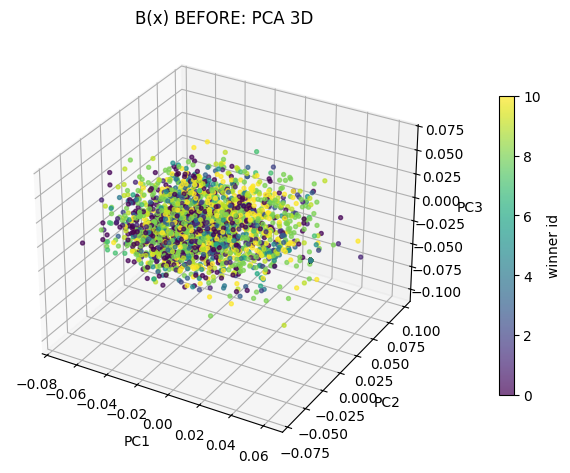

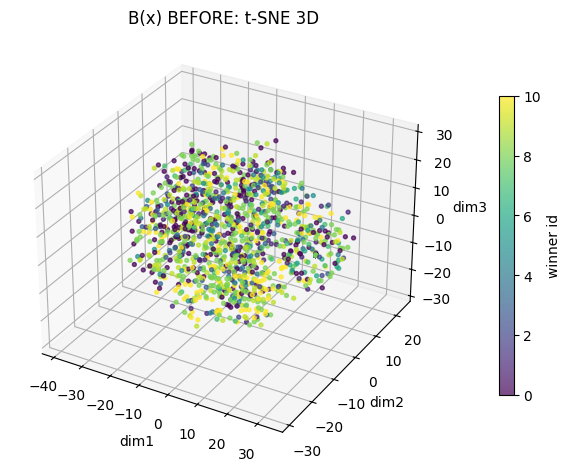

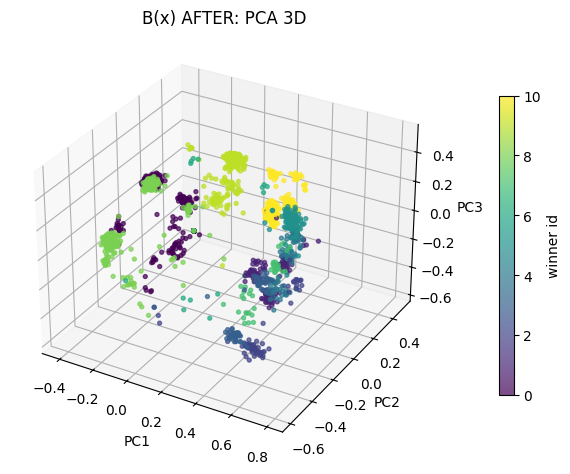

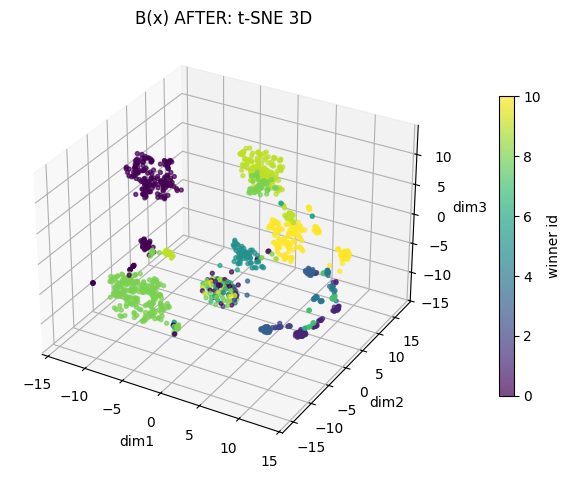

In [62]:
# BEFORE (Z0, y0가 있다고 가정)
plot_pca_3d(Z0, labels=y0, title="B(x) BEFORE: PCA 3D")
plot_tsne_3d(Z0, labels=y0, title="B(x) BEFORE: t-SNE 3D", tsne_n=1500, perplexity=30)

# AFTER (Z1, y1가 있다고 가정)
plot_pca_3d(Z1, labels=y1, title="B(x) AFTER: PCA 3D")
plot_tsne_3d(Z1, labels=y1, title="B(x) AFTER: t-SNE 3D", tsne_n=1500, perplexity=30)


In [63]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def probe_separability(Z, y, seed=0):
    Xtr, Xte, ytr, yte = train_test_split(Z, y, test_size=0.3, random_state=seed, stratify=y)

    # kNN
    knn = KNeighborsClassifier(n_neighbors=20, metric="cosine")
    knn.fit(Xtr, ytr)
    pred_knn = knn.predict(Xte)
    acc_knn = accuracy_score(yte, pred_knn)

    # linear probe (logistic regression)
    clf = LogisticRegression(max_iter=2000, n_jobs=-1, multi_class="auto")
    clf.fit(Xtr, ytr)
    pred_lr = clf.predict(Xte)
    acc_lr = accuracy_score(yte, p# =========================
# [Cell] Train 곡선 기록 + 플롯
# =========================
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import clear_output

# 1) pos_mask density 체크
@torch.no_grad()
def posmask_density(router, ub, cfg):
    pos_strategy = str(cfg.supcon_pos_strategy).lower().strip()
    if pos_strategy == "top1":
        y = ub.argmax(dim=1)
        pos_mask = (y.unsqueeze(1) == y.unsqueeze(0)).float()
        pos_mask.fill_diagonal_(0.0)
    elif pos_strategy == "topr_mass":
        pos_mask = router.build_pos_mask_adaptive_topk(
            util_batch=ub,
            max_k=int(cfg.supcon_topk_max_k),
            mode="mass",
            beta=float(cfg.supcon_topk_beta),
            q=float(cfg.supcon_topk_q),
        )
    elif pos_strategy == "topr_margin":
        pos_mask = router.build_pos_mask_adaptive_topk(
            util_batch=ub,
            max_k=int(cfg.supcon_topk_max_k),
            mode="margin",
            delta=float(cfg.supcon_topk_delta),
        )
    else:
        raise ValueError("bad pos_strategy")

    B = pos_mask.shape[0]
    avg_pos_cnt = float((pos_mask > 1e-6).float().sum(dim=1).mean().item())  # row당 positive 수
    density = float((pos_mask > 1e-6).float().mean().item())                 # 전체 밀도
    return avg_pos_cnt, density

# 2) SupCon loss 평가(gradient 없이)
@torch.no_grad()
def eval_supcon_loss(router, X_np, U_np, cfg, n_batches=3, seed=0):
    router.eval()
    X = torch.from_numpy(X_np).float().to(router.device)
    U = torch.from_numpy(U_np).float().to(router.device)
    N = X.shape[0]
    bs = min(int(cfg.supcon_bs), N)
    replace = (N < bs)
    rng = np.random.RandomState(seed)

    losses = []
    for _ in range(n_batches):
        idx = rng.choice(N, size=bs, replace=replace)
        xb = X[idx]
        ub = U[idx]
        z = router.forward_ctx_supcon(xb)

        pos_strategy = str(cfg.supcon_pos_strategy).lower().strip()
        if pos_strategy == "top1":
            y = ub.argmax(dim=1)
            pos_mask = (y.unsqueeze(1) == y.unsqueeze(0)).float()
            pos_mask.fill_diagonal_(0.0)
        elif pos_strategy == "topr_mass":
            pos_mask = router.build_pos_mask_adaptive_topk(
                util_batch=ub,
                max_k=int(cfg.supcon_topk_max_k),
                mode="mass",
                beta=float(cfg.supcon_topk_beta),
                q=float(cfg.supcon_topk_q),
            )
        elif pos_strategy == "topr_margin":
            pos_mask = router.build_pos_mask_adaptive_topk(
                util_batch=ub,
                max_k=int(cfg.supcon_topk_max_k),
                mode="margin",
                delta=float(cfg.supcon_topk_delta),
            )
        else:
            raise ValueError("bad pos_strategy")

        loss = router.supcon_loss_posmask(z, pos_mask)
        losses.append(float(loss.item()))
    return float(np.mean(losses))

# 3) collapse 지표(빠르게: fixed subset + pairwise cosine 샘플)
@torch.no_grad()
def collapse_metrics(router, X_np, U_np=None, n_vis=1500, max_pairs=100000, seed=0):
    router.eval()
    rng = np.random.RandomState(seed)
    N = X_np.shape[0]
    take = min(int(n_vis), N)
    idx = rng.choice(N, size=take, replace=False)

    X = torch.from_numpy(X_np[idx]).float().to(router.device)
    Z = F.normalize(router.B(X), dim=-1).detach().cpu().numpy()

    # pairwise cosine 샘플
    P = min(int(max_pairs), take * (take - 1) // 2)
    i = rng.randint(0, take, size=P)
    j = rng.randint(0, take, size=P)
    m = i != j
    i, j = i[m], j[m]
    cos = np.sum(Z[i] * Z[j], axis=1)

    out = {
        "collapse_std_mean": float(Z.std(axis=0).mean()),
        "cos_mean_offdiag": float(cos.mean()),
        "cos_p50": float(np.percentile(cos, 50)),
        "cos_p95": float(np.percentile(cos, 95)),
    }

    if U_np is not None:
        y = np.argmax(U_np[idx], axis=1).astype(np.int64)
        same = (y[i] == y[j])
        if same.any() and (~same).any():
            out["within_cos_mean"] = float(cos[same].mean())
            out["between_cos_mean"] = float(cos[~same].mean())
            out["within_minus_between"] = float(cos[same].mean() - cos[~same].mean())
        else:
            out["within_minus_between"] = float("nan")
    return out

# 4) 학습 루프 + 실시간 플롯
def train_B_with_live_plots(router, X_tr, U_tr, X_va, U_va, cfg,
                            log_every=25, eval_batches=3, n_vis=1500):
    N = X_tr.shape[0]
    router.unfreeze_B(lr_b=float(cfg.offline_lr_B))

    rng = np.random.RandomState(cfg.seed + 2024)
    X_t = torch.from_numpy(X_tr).float().to(router.device)
    U_t = torch.from_numpy(U_tr).float().to(router.device)

    bs = int(cfg.supcon_bs)
    replace = (N < bs)
    pos_strategy = str(cfg.supcon_pos_strategy).lower().strip()

    hist = {
        "ep": [],
        "loss_train_batch": [],
        "loss_train_eval": [],
        "loss_val_eval": [],
        "avg_pos_cnt": [],
        "pos_density": [],
        "collapse_std": [],
        "cos_mean": [],
        "wmb": [],
    }

    print(f"[Train] N_tr={len(X_tr)} N_val={len(X_va)} bs={bs} epochs={cfg.offline_epochs} pos={pos_strategy} lr={cfg.offline_lr_B}")

    for ep in range(1, int(cfg.offline_epochs) + 1):
        b_idx_np = rng.choice(N, size=bs, replace=replace)
        b_idx = torch.as_tensor(b_idx_np, device=router.device, dtype=torch.long)

        xb = X_t[b_idx]
        ub = U_t[b_idx]

        router.train()
        router.opt_b.zero_grad(set_to_none=True)

        z = router.forward_ctx_supcon(xb)

        if pos_strategy == "top1":
            y = ub.argmax(dim=1)
            pos_mask = (y.unsqueeze(1) == y.unsqueeze(0)).float()
            pos_mask.fill_diagonal_(0.0)
        elif pos_strategy == "topr_mass":
            pos_mask = router.build_pos_mask_adaptive_topk(
                util_batch=ub, max_k=int(cfg.supcon_topk_max_k),
                mode="mass", beta=float(cfg.supcon_topk_beta), q=float(cfg.supcon_topk_q)
            )
        elif pos_strategy == "topr_margin":
            pos_mask = router.build_pos_mask_adaptive_topk(
                util_batch=ub, max_k=int(cfg.supcon_topk_max_k),
                mode="margin", delta=float(cfg.supcon_topk_delta)
            )
        else:
            raise ValueError("bad pos_strategy")

        loss = router.supcon_loss_posmask(z, pos_mask)
        loss.backward()
        router.opt_b.step()

        if (ep % log_every == 0) or (ep == 1) or (ep == int(cfg.offline_epochs)):
            # density는 현재 배치로
            apc, dens = posmask_density(router, ub, cfg)

            # train/val loss (eval)
            ltr = eval_supcon_loss(router, X_tr, U_tr, cfg, n_batches=eval_batches, seed=ep)
            lva = eval_supcon_loss(router, X_va, U_va, cfg, n_batches=eval_batches, seed=ep + 999)

            # collapse metric (val쪽에서 보는 게 보통 더 안전)
            cm = collapse_metrics(router, X_va, U_va, n_vis=n_vis, max_pairs=min(cfg.max_pairs, 100000), seed=0)

            hist["ep"].append(ep)
            hist["loss_train_batch"].append(float(loss.item()))
            hist["loss_train_eval"].append(ltr)
            hist["loss_val_eval"].append(lva)
            hist["avg_pos_cnt"].append(apc)
            hist["pos_density"].append(dens)
            hist["collapse_std"].append(cm["collapse_std_mean"])
            hist["cos_mean"].append(cm["cos_mean_offdiag"])
            hist["wmb"].append(cm.get("within_minus_between", np.nan))

            # --- live plot ---
            clear_output(wait=True)
            fig = plt.figure(figsize=(14, 10))

            # loss
            ax1 = fig.add_subplot(2, 2, 1)
            ax1.plot(hist["ep"], hist["loss_train_eval"], label="train_eval")
            ax1.plot(hist["ep"], hist["loss_val_eval"], label="val_eval")
            ax1.set_title("SupCon loss (eval)")
            ax1.set_xlabel("epoch")
            ax1.grid(True)
            ax1.legend()

            # collapse std
            ax2 = fig.add_subplot(2, 2, 2)
            ax2.plot(hist["ep"], hist["collapse_std"], label="collapse_std_mean")
            ax2.set_title("Collapse std (higher is better)")
            ax2.set_xlabel("epoch")
            ax2.grid(True)
            ax2.legend()

            # cosine mean
            ax3 = fig.add_subplot(2, 2, 3)
            ax3.plot(hist["ep"], hist["cos_mean"], label="cos_mean_offdiag")
            ax3.set_title("Pairwise cosine mean (lower is better)")
            ax3.set_xlabel("epoch")
            ax3.grid(True)
            ax3.legend()

            # pos density + wmb
            ax4 = fig.add_subplot(2, 2, 4)
            ax4.plot(hist["ep"], hist["avg_pos_cnt"], label="avg_pos_cnt")
            ax4.plot(hist["ep"], hist["pos_density"], label="pos_density")
            ax4.plot(hist["ep"], hist["wmb"], label="within_minus_between")
            ax4.set_title("Positives + separation")
            ax4.set_xlabel("epoch")
            ax4.grid(True)
            ax4.legend()

            plt.tight_layout()
            plt.show()

            print(f"ep={ep}  batch_loss={loss.item():.4f}  train_eval={ltr:.4f}  val_eval={lva:.4f}  "
                  f"avg_pos={apc:.1f} dens={dens:.3f}  "
                  f"std={cm['collapse_std_mean']:.4f}  cos_mean={cm['cos_mean_offdiag']:.4f}  wmb={cm.get('within_minus_between', np.nan):.4f}")

    router.freeze_B()
    router.eval()
    return hist
red_lr)

    return {"knn_acc": acc_knn, "linear_acc": acc_lr}

# BEFORE/AFTER 비교
print("BEFORE probe:", probe_separability(Z0, y0))
print("AFTER  probe:", probe_separability(Z1, y1))


SyntaxError: invalid syntax (1410351052.py, line 22)

plotly가 없거나 동작이 안 돼서 matplotlib 3D로 그린다: No module named 'plotly'


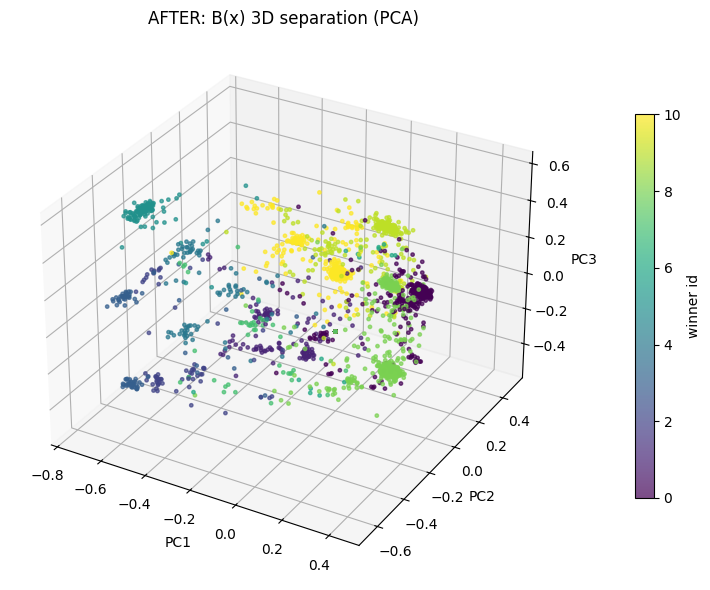

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.decomposition import PCA

# 1) B(x) 뽑기 (학습 후 router)
@torch.no_grad()
def get_Z_after(router, X_np, U_np=None, n_vis=3000, seed=0):
    router.eval()
    rng = np.random.RandomState(seed)
    N = X_np.shape[0]
    idx = rng.choice(N, size=min(n_vis, N), replace=False)

    X = torch.from_numpy(X_np[idx]).float().to(router.device)
    Z = router.B(X)
    Z = F.normalize(Z, dim=-1).detach().cpu().numpy()  # (n_vis, d_proj)

    y = None
    if U_np is not None:
        y = np.argmax(U_np[idx], axis=1).astype(np.int64)  # winner label
    return Z, y, idx

# 2) 3D로 줄이기(PCA 3D) + 3D scatter (Plotly 우선, 없으면 matplotlib)
def plot_3d_separation(Z, y=None, title="B(x) separation in 3D (PCA)"):
    Z3 = PCA(n_components=3, random_state=0).fit_transform(Z)

    # Plotly (회전/줌이 편하다)
    try:
        import plotly.express as px
        df = {
            "x": Z3[:, 0],
            "y": Z3[:, 1],
            "z": Z3[:, 2],
        }
        if y is not None:
            df["winner"] = y.astype(str)
            fig = px.scatter_3d(df, x="x", y="y", z="z", color="winner", opacity=0.7, title=title)
        else:
            fig = px.scatter_3d(df, x="x", y="y", z="z", opacity=0.7, title=title)
        fig.update_traces(marker=dict(size=3))
        fig.show()
        return
    except Exception as e:
        print("plotly가 없거나 동작이 안 돼서 matplotlib 3D로 그린다:", str(e))

    # matplotlib (회전은 제한적일 수 있다)
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    if y is None:
        ax.scatter(Z3[:, 0], Z3[:, 1], Z3[:, 2], s=6, alpha=0.6)
    else:
        sc = ax.scatter(Z3[:, 0], Z3[:, 1], Z3[:, 2], c=y, s=6, alpha=0.7)
        fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.1, label="winner id")

    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    plt.tight_layout()
    plt.show()

# ===== 실행 =====
Z_after, y_after, _ = get_Z_after(router, X_off, U_off, n_vis=3000, seed=0)
plot_3d_separation(Z_after, y_after, title="AFTER: B(x) 3D separation (PCA)")


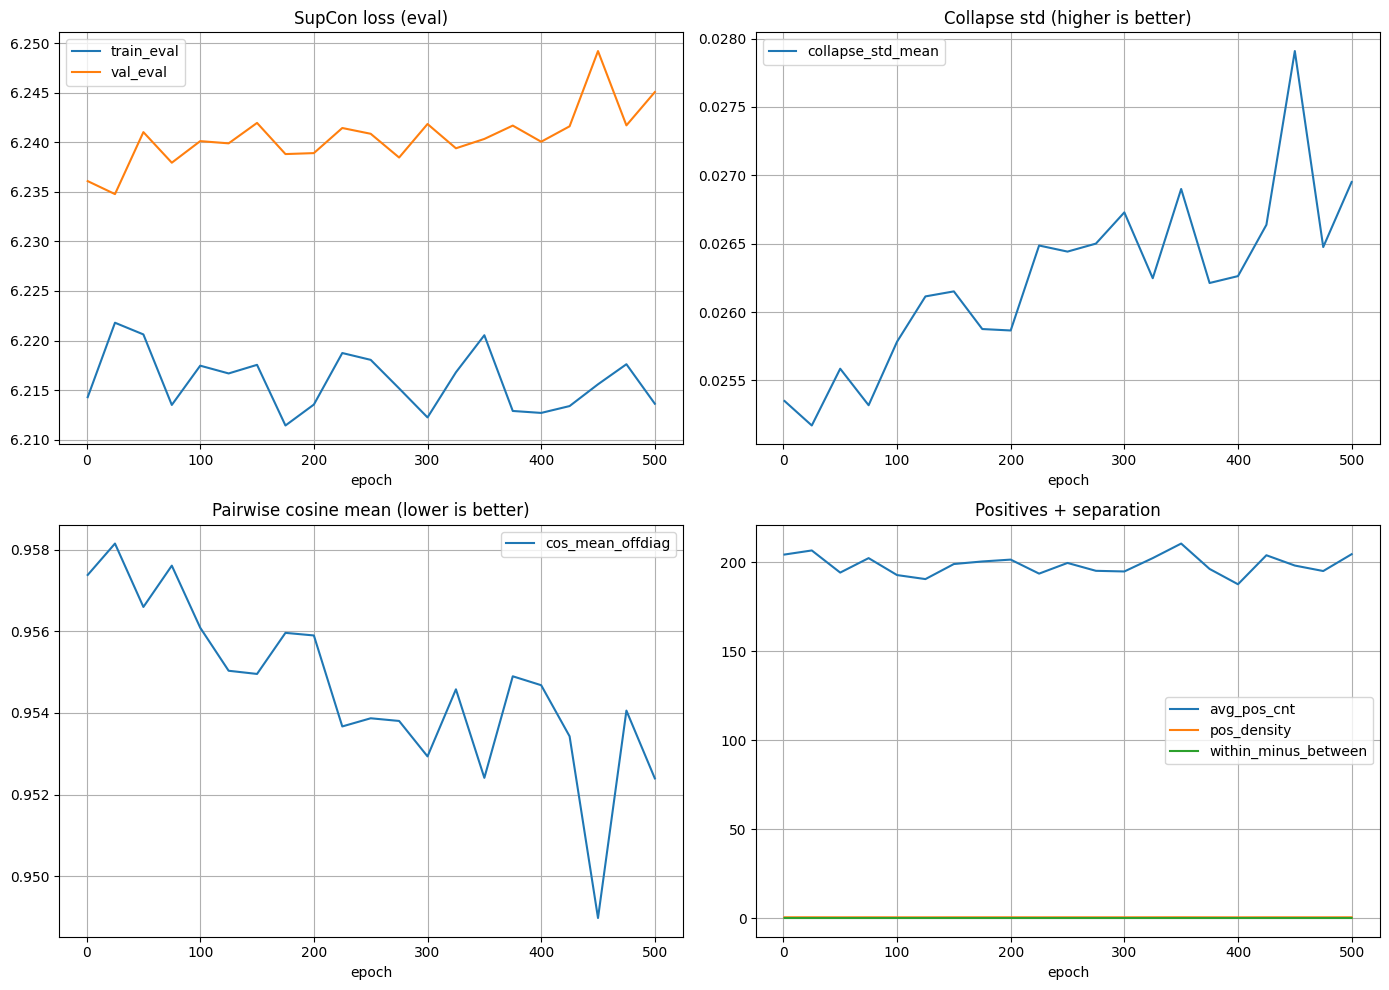

ep=500  batch_loss=6.2175  train_eval=6.2136  val_eval=6.2451  avg_pos=204.7 dens=0.400  std=0.0270  cos_mean=0.9524  wmb=0.0017


In [ ]:
hist = train_B_with_live_plots(
    router,
    X_off_tr, U_off_tr,
    X_off_va, U_off_va,
    cfg,
    log_every=25,
    eval_batches=3,
    n_vis=1500
)
